In [1]:
import pandas as pd
import numpy as np
import re
import html
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import string
import nltk
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
nltk.download('all')

sns.set(style="whitegrid")

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

In [2]:
train_url = 'https://drive.google.com/file/d/1FaHdT2UOnPgT7Enl-EYxrqLM8vwfBKrh/view'
id = train_url.split("/")[-2]
new_link = f'https://drive.google.com/uc?id={id}'
train_df = pd.read_csv(new_link)

In [3]:
print("Shape:", train_df.shape)
print("\nColumns:", train_df.columns.tolist())
print("\nInfo:")
print(train_df.info())
print("\nMissing values:")
print(train_df.isnull().sum())
print("\nClass distribution:")
print(train_df["News Topic"].value_counts())
print("\nClass percentages:")
print((train_df["News Topic"].value_counts(normalize=True) * 100).round(2))

Shape: (95440, 2)

Columns: ['News Headline', 'News Topic']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95440 entries, 0 to 95439
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   News Headline  95440 non-null  object
 1   News Topic     95440 non-null  object
dtypes: object(2)
memory usage: 1.5+ MB
None

Missing values:
News Headline    0
News Topic       0
dtype: int64

Class distribution:
News Topic
Business                  30563
Sports                    26773
World News                24415
Science and Technology    13689
Name: count, dtype: int64

Class percentages:
News Topic
Business                  32.02
Sports                    28.05
World News                25.58
Science and Technology    14.34
Name: proportion, dtype: float64


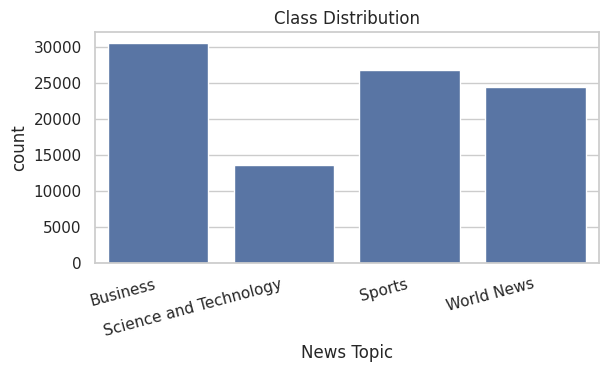

In [4]:
plt.figure(figsize=(6.5,3))
sns.countplot(x='News Topic', data=train_df)
plt.xticks(rotation=15, ha='right')
plt.title("Class Distribution")
plt.show()

In [5]:
for label in train_df['News Topic'].unique():
    print(label)
    print(train_df[train_df['News Topic'] == label]['News Headline'].iloc[0])

Business
<html> <body> News Headlines:
 <br> <b> Presidential plans fail on good-tax basics If taxes are the price of civilization, election year is the time for bargain hunting. Over the past few months, President Bush and Sen. John Kerry, D-Mass. </b> 
 <br> <br> 
Science and Technology
<html> <body> News Headlines:
 <br> <b> Will Fiorina Be Merger Casualty? Hewlett-Packard CEO #39;s job could be on chopping block along with 15,000 others if Compaq deal goes through. Watch  #39;Tech Live #39; Wednesday 3/20 at 9 pm Eastern for details. </b> 
 <br> <br> 
Sports
<html> <body> News Headlines:
 <br> <b> Fish Beats Hernych at St. Petersburg Olympic silver medalist Mardy Fish beat Jan Hernych of the Czech Republic 6-2, 6-4 Monday to reach the second round of the St. Petersburg Open. </b> 
 <br> <br> 
World News
<html> <body> News Headlines:
 <br> <b> 2 Indonesians held in Iraq BAGHDAD - Two Indonesian women working for an electricity firm are among 10 new hostages reported seized by milita

In [6]:
import re, html

def clean_text(text):
    text = html.unescape(str(text))
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"#\d+;", " ", text)
    text = re.sub(r"[^A-Za-z\s]", " ", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["clean"] = train_df["News Headline"].apply(clean_text)

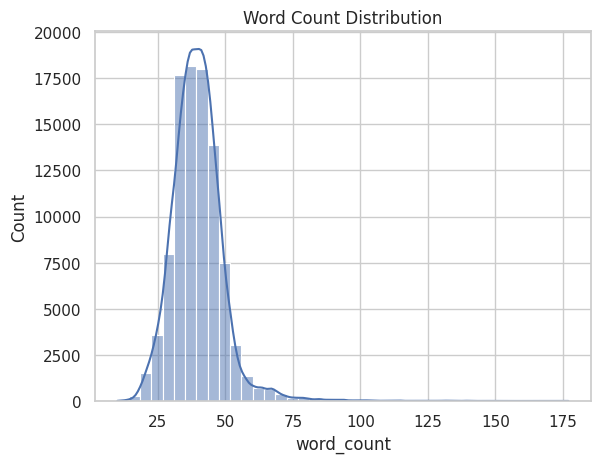

In [7]:
train_df["word_count"] = train_df["clean"].apply(lambda x: len(x.split()))

sns.histplot(train_df["word_count"], bins=40, kde=True)
plt.title("Word Count Distribution")
plt.show()

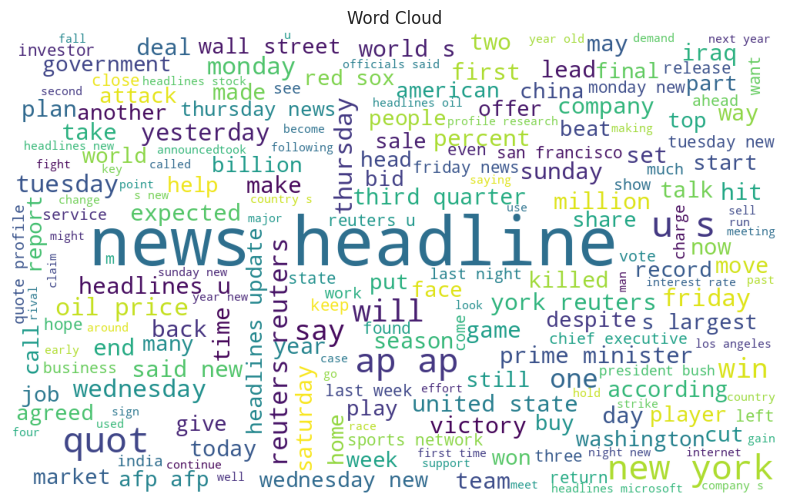

In [8]:
from wordcloud import WordCloud

text = " ".join(train_df['clean'])
wc = WordCloud(width=1000, height=600, background_color= 'white').generate(text)

plt.figure(figsize = (10,6))
plt.axis("off")
plt.title("Word Cloud")
plt.imshow(wc)

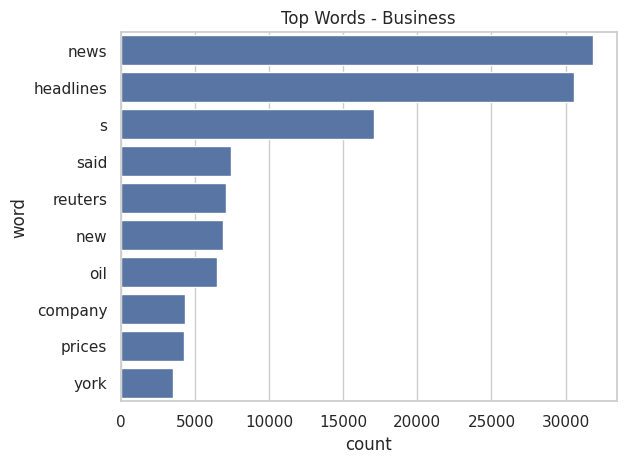

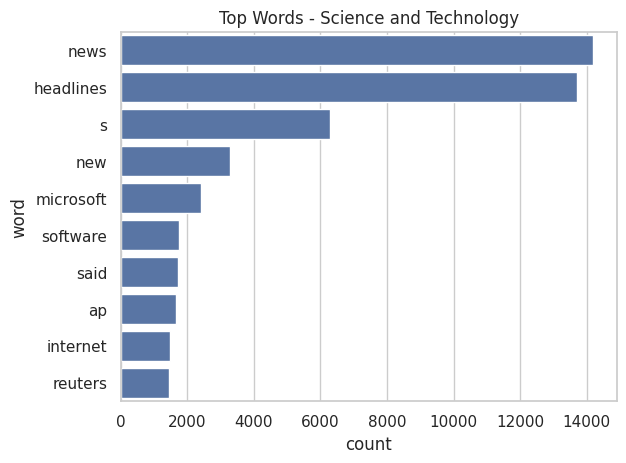

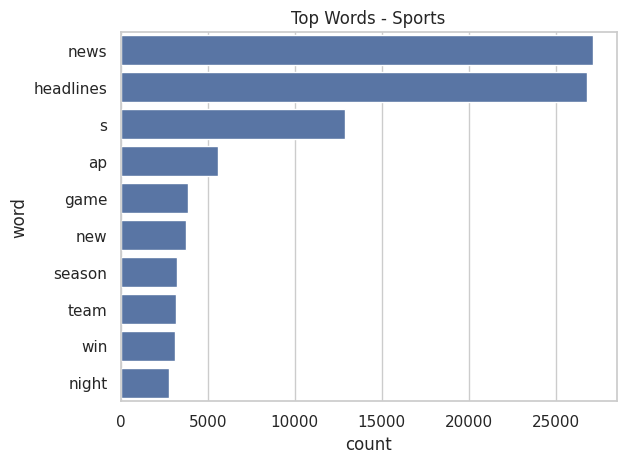

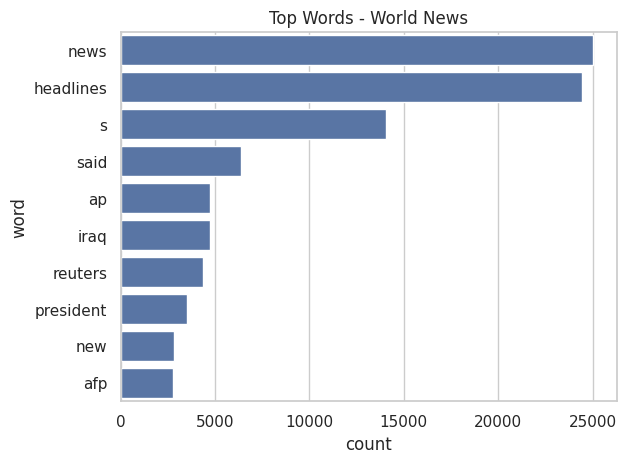

In [9]:
for label in train_df["News Topic"].unique():
    subset = train_df[train_df["News Topic"] == label]["clean"]

    tokens = []
    for t in subset:
        tokens.extend([w for w in t.split() if w not in ENGLISH_STOP_WORDS])

    top_words = Counter(tokens).most_common(10)
    df = pd.DataFrame(top_words, columns=["word", "count"])

    sns.barplot(data=df, x="count", y="word")
    plt.title(f"Top Words - {label}")
    plt.show()

In [16]:
# Avg word & character count per class
train_df['word_count'] = train_df['News Headline'].apply(lambda x: len(x.split()))
train_df['char_count'] = train_df['News Headline'].apply(lambda x: len(x))
print(train_df.groupby('News Topic')[['word_count', 'char_count']].mean().round(2))

                        word_count  char_count
News Topic                                    
Business                     46.51      299.15
Science and Technology       46.17      294.78
Sports                       46.76      282.56
World News                   47.86      300.45


# **Preprocessing & Compare**

In [10]:
X_train = train_df['News Headline']

In [11]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

Optimum

In [12]:
def optimum_preprocess(text):
    text = text.lower()

    text = re.sub(r'<.*?>', '', text)

    text = text.replace("news headlines:", "")

    text = re.sub(r'[^a-z\s]', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()

    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

X_train_optimum = X_train.apply(optimum_preprocess)

Extreme

In [13]:
def extreme_preprocess(text):
    text = text.lower()

    text = re.sub(r'<.*?>', '', text)

    text = text.replace("news headlines:", "")

    text = re.sub(r'[^a-z\s]', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()

    words = [w for w in words if w not in stop_words]

    words = [w for w in words if len(w) > 2]

    words = [stemmer.stem(w) for w in words]

    return " ".join(words)

X_train_extreme = X_train.apply(extreme_preprocess)

In [15]:
# Vocab size comparison
def vocab_size(series):
    return len(set(" ".join(series).split()))

print("Vocabulary Size")
print(f"No Preprocessing:      {vocab_size(X_train)}")
print(f"Optimum Preprocessing: {vocab_size(X_train_optimum)}")
print(f"Extreme Preprocessing: {vocab_size(X_train_extreme)}")

# Avg word count per preprocessing
print("\nAvg Tokens Per Headline")
for name, series in [("No Preprocessing", X_train), ("Optimum", X_train_optimum), ("Extreme", X_train_extreme)]:
    print(f"{name}: {series.apply(lambda x: len(x.split())).mean():.2f}")

Vocabulary Size
No Preprocessing:      152016
Optimum Preprocessing: 68597
Extreme Preprocessing: 56528

Avg Tokens Per Headline
No Preprocessing: 46.88
Optimum: 36.71
Extreme: 24.13
